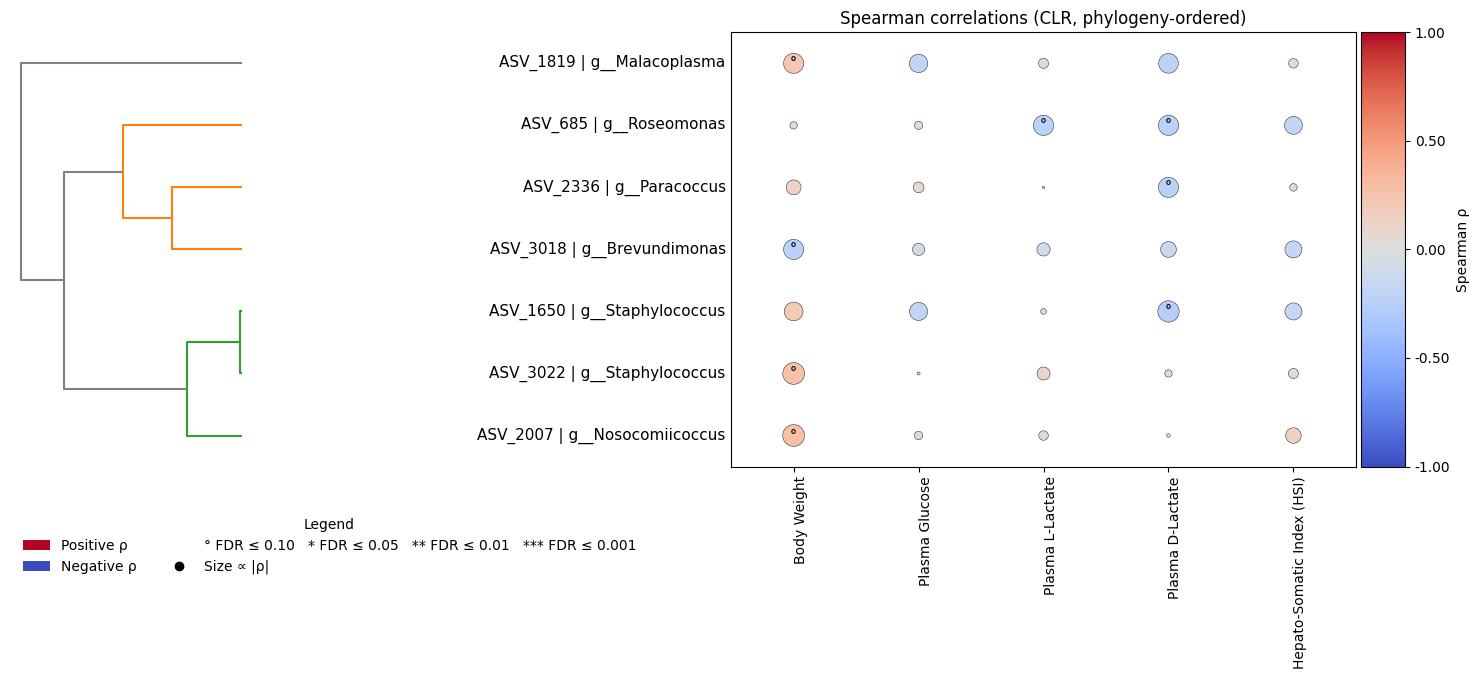

In [7]:
# ==== Spearman (CLR) corrplot-style circles + colored dendrogram + asterisk sig ====
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
from skbio.stats.composition import clr, multiplicative_replacement
from biom import load_table

# ---------- CONFIG ----------
biom_file     = "output_files/mucus_filtered_table_with_taxonomy.biom"
metadata_file = "output_files/metadata_model_used_for_BIRDMAn.tsv"
tree_file     = "input_files/tree.nwk"

physio_cols   = ["Body_Weight", "Plasma_Glucose", "Plasma_L-Lactate", "Plasma_D-Lactate", "HSI"]
fdr_alpha     = 0.1
min_nonzero   = 3
only_signif   = True
top_n         = None

cmap_name     = "coolwarm"
label_fontsize= 11
sym_vlim      = 1.0  # None = auto

# Layout
dendro_col      = 3.2
gap_col         = 0.0
labels_col_base = 6.5
heat_col        = 8.6
cbar_col        = 0.6
fig_width       = 18.0

# Circle (corrplot) options
cell_style   = "circle"   # "circle" for corrplot; set to "rect" for classic heatmap
circle_scale = 900        # size for |rho|=1
circle_edge  = True       # outline around circles

# Output directory
out_dir = os.path.join("export_for_R", "spearman_corr_mucus")
os.makedirs(out_dir, exist_ok=True)

# ====== 0. Load counts from BIOM ======
filt_tbl = load_table(biom_file)
obs_ids  = filt_tbl.ids(axis="observation")
samp_ids = filt_tbl.ids(axis="sample")
X        = filt_tbl.matrix_data.toarray()
counts_df = pd.DataFrame(X, index=obs_ids, columns=samp_ids)

# taxonomy labels
def deepest_nonempty_with_prefix(meta, max_len=80):
    tx = (meta or {}).get("taxonomy") or []
    if isinstance(tx, str): tx = [t.strip() for t in tx.split(";")]
    for r in reversed(tx):
        r = r.strip()
        if not r: continue
        if "__" in r:
            pre, val = r.split("__", 1); val = val.strip()
            if val:
                out = f"{pre}__{val}"
                return (out[:max_len-1] + "…") if len(out) > max_len else out
        else:
            return (r[:max_len-1] + "…") if len(r) > max_len else r
    return None

asv_to_label = {}
for asv in obs_ids:
    meta = filt_tbl.metadata(asv, axis="observation") or {}
    d = deepest_nonempty_with_prefix(meta)
    asv_to_label[asv] = f"{asv} | {d}" if d else asv

label_map = pd.Series(asv_to_label, name="asv_label").to_dict()

# ====== 1. Load metadata ======
metadata = pd.read_csv(metadata_file, sep="\t", index_col=0)
metadata_model = metadata[
    (metadata["sample_type"] == "Mucus") &
    (metadata["Diet"].isin(["NC", "HC"]))
].copy()
metadata_model["Diet"] = pd.Categorical(metadata_model["Diet"], categories=["HC","NC"])

# ====== 2. Extract counts aligned to metadata ======
counts_numeric = counts_df.loc[:, metadata_model.index]

# ====== 3. CLR transform ======
X = counts_numeric.values.astype(float)
X_repl = multiplicative_replacement(X)
X_clr  = clr(X_repl)
abund_clr_df = pd.DataFrame(X_clr, index=counts_numeric.index, columns=counts_numeric.columns)

# ====== 4. Spearman correlations ======
common = abund_clr_df.columns.intersection(metadata_model.index)
abund  = abund_clr_df[common].T
meta   = metadata_model.loc[common, physio_cols]
mask_good = ~meta[physio_cols].isna().any(axis=1)
abund = abund.loc[mask_good]
meta  = meta.loc[mask_good]

features = abund.columns.tolist()
phis     = physio_cols
rho_mat  = np.full((len(features), len(phis)), np.nan, float)
p_mat    = np.full_like(rho_mat, np.nan, float)

feat_idx = {f:i for i,f in enumerate(features)}
valid_feats = [f for f in features if np.count_nonzero(abund[f].values) >= min_nonzero]

for feat in valid_feats:
    i = feat_idx[feat]
    x = abund[feat].values
    for j, ph in enumerate(phis):
        y = meta[ph].values
        r, p = spearmanr(x, y, nan_policy="omit")
        rho_mat[i, j] = r
        p_mat[i, j]   = p

# ====== 5. FDR correction (+ optional filtering) ======
mask_fin   = np.isfinite(p_mat)
p_adj_mat  = np.full_like(p_mat, np.nan, float)
if mask_fin.any():
    _, p_fdr, _, _ = multipletests(p_mat[mask_fin], alpha=fdr_alpha, method="fdr_bh")
    p_adj_mat[mask_fin] = p_fdr

rho_df   = pd.DataFrame(rho_mat, index=features, columns=phis).dropna(how="all")
p_adj_df = pd.DataFrame(p_adj_mat, index=features, columns=phis).loc[rho_df.index]

if only_signif:
    keep = (p_adj_df <= fdr_alpha).any(axis=1)
    rho_df   = rho_df.loc[keep]
    p_adj_df = p_adj_df.loc[keep]

if top_n is not None and len(rho_df) > top_n:
    order_tmp = (rho_df.abs().max(axis=1)).sort_values(ascending=False).index[:top_n]
    rho_df   = rho_df.loc[order_tmp]
    p_adj_df = p_adj_df.loc[order_tmp]

row_names = rho_df.index.tolist()
if rho_df.shape[0] == 0:
    raise ValueError("No taxa passed the significance filter.")

# ====== 6. Phylogeny ordering + colored dendrogram (robust threshold) ======
def tip_name_from_feature(feat: str) -> str | None:
    return feat.split(" | ", 1)[0].strip()

show_dendro = False
Z = None
t_for_plot = None

if os.path.exists(tree_file) and len(row_names) > 1:
    try:
        from Bio import Phylo
        from scipy.cluster.hierarchy import linkage, leaves_list, optimal_leaf_ordering, dendrogram

        tree = Phylo.read(tree_file, "newick")
        tip_names = {t.name for t in tree.get_terminals() if t.name is not None}
        row_to_tip = {r: tip_name_from_feature(r) for r in row_names}
        present_rows = [r for r in row_names if row_to_tip.get(r) in tip_names]

        if len(present_rows) >= 2:
            n = len(present_rows)
            D = np.zeros(n * (n - 1) // 2, float)
            k = 0
            for i in range(n - 1):
                for j in range(i + 1, n):
                    d_ij = tree.distance(row_to_tip[present_rows[i]], row_to_tip[present_rows[j]])
                    D[k] = float(d_ij) if np.isfinite(d_ij) else 0.0
                    k += 1

            if not np.allclose(D, 0):
                Z = linkage(D, method="average")
                Z = optimal_leaf_ordering(Z, D)
                order_present = leaves_list(Z)
                ordered_present_rows = [present_rows[i] for i in order_present]
                missing_rows = [r for r in row_names if r not in present_rows]
                miss_order = (rho_df.loc[missing_rows].abs().max(axis=1).sort_values(ascending=False).index.tolist()) if missing_rows else []
                new_order = ordered_present_rows + miss_order
                rho_df   = rho_df.loc[new_order]
                p_adj_df = p_adj_df.loc[new_order]
                row_names = new_order
                show_dendro = True

                # robust non-zero threshold for coloring
                z_heights = Z[:, 2]
                zmax = float(np.nanmax(z_heights)) if z_heights.size else 0.0
                t_for_plot = 0.7 * zmax if zmax > 0 else 1e-12
            else:
                order = rho_df.abs().max(axis=1).sort_values(ascending=False).index
                rho_df = rho_df.loc[order]; p_adj_df = p_adj_df.loc[order]; row_names = list(order)
        else:
            order = rho_df.abs().max(axis=1).sort_values(ascending=False).index
            rho_df = rho_df.loc[order]; p_adj_df = p_adj_df.loc[order]; row_names = list(order)
    except Exception as e:
        print(f"[phylo] failed ({e}); falling back to |rho| ordering.")
        order = rho_df.abs().max(axis=1).sort_values(ascending=False).index
        rho_df = rho_df.loc[order]; p_adj_df = p_adj_df.loc[order]; row_names = list(order)

# ====== Rename column names for plotting ======
rename_map = {
    "Body_Weight": "Body Weight",
    "Plasma_Glucose": "Plasma Glucose",
    "Plasma_L-Lactate": "Plasma L-Lactate",
    "Plasma_D-Lactate": "Plasma D-Lactate",
    "HSI": "Hepato-Somatic Index (HSI)"
}

rho_df   = rho_df.rename(columns=rename_map)
p_adj_df = p_adj_df.rename(columns=rename_map)



# ====== 7. Plot: corrplot-style circles (linear size) + asterisk significance ======
# Safe defaults if not already defined above
cell_style   = locals().get("cell_style", "circle")
circle_scale = locals().get("circle_scale", 400)   # try 300–500 if overlap
circle_edge  = locals().get("circle_edge", True)

label_fontsize    = locals().get("label_fontsize", 9)
labels_col_base   = locals().get("labels_col_base", 3.2)
dendro_col        = locals().get("dendro_col", 3.2)
gap_col           = locals().get("gap_col", 0.0)
heat_col          = locals().get("heat_col", 8.6)
cbar_col          = locals().get("cbar_col", 0.6)
fig_width         = locals().get("fig_width", 18.0)
cmap_name         = locals().get("cmap_name", "coolwarm")
sym_vlim          = locals().get("sym_vlim", 1.0)
out_base          = locals().get("out_base", "spearman_corrplot_clr_phylo")
dpi_save          = locals().get("dpi_save", 300)

# Ensure p_adj_df matches rho_df rows/cols (important after renaming)
p_adj_df = p_adj_df.reindex(index=rho_df.index, columns=rho_df.columns)

def p_to_stars(p):
    if p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    elif p <= 0.10:
        return "°"
    else:
        return ""

vals = rho_df.values
cmap_obj = mpl.colormaps.get_cmap(cmap_name)
vabs = (np.nanmax(np.abs(vals)) if sym_vlim is None else float(sym_vlim))
if not np.isfinite(vabs) or vabs == 0:
    vabs = 1.0

# Left labels
render_labels = [label_map.get(r, r) for r in rho_df.index]
max_label_len = max((len(str(n)) for n in render_labels), default=10)
# Give extra room to labels
labels_col = max(labels_col_base, 0.16 * (max_label_len / 10.0) * 10)

# Taller figure to reduce clutter
fig_h = max(6, 0.24 * len(rho_df))
fig = plt.figure(figsize=(fig_width, fig_h + 1.2))

# Robust dendrogram availability
show_den = bool(locals().get("show_dendro", False)) and (locals().get("Z", None) is not None)
t_for_plot = locals().get("t_for_plot", None)
if show_den and (t_for_plot is None or t_for_plot <= 0):
    # compute a non-zero threshold from Z heights
    z_heights = Z[:, 2] if Z is not None and Z.size else np.array([])
    if z_heights.size > 0 and np.nanmax(z_heights) > 0:
        t_for_plot = 0.7 * float(np.nanmax(z_heights))
    else:
        t_for_plot = 1e-12

if show_den:
    gs = GridSpec(nrows=2, ncols=5,
                  width_ratios=[dendro_col, gap_col, labels_col, heat_col, cbar_col],
                  height_ratios=[1.0, 0.12], wspace=0.02, hspace=0.28)
    ax_den = fig.add_subplot(gs[0, 0])
    ax_gap = fig.add_subplot(gs[0, 1]); ax_gap.axis("off")
    ax_lab = fig.add_subplot(gs[0, 2])
    ax_hm  = fig.add_subplot(gs[0, 3])
    cax    = fig.add_subplot(gs[0, 4])
    lax    = fig.add_subplot(gs[1, :])

    from scipy.cluster.hierarchy import dendrogram
    dendrogram(
        Z, orientation="left", ax=ax_den, no_labels=True,
        color_threshold=float(t_for_plot),
        above_threshold_color="#808080",
    )
    ax_den.invert_yaxis(); ax_den.axis("off"); ax_den.margins(x=0.08)
else:
    gs = GridSpec(nrows=2, ncols=3,
                  width_ratios=[labels_col + heat_col + dendro_col + gap_col, cbar_col, 0.01],
                  height_ratios=[1.0, 0.12], wspace=0.02, hspace=0.28)
    ax_lab = fig.add_subplot(gs[0, 0])
    ax_hm  = ax_lab.twinx()
    cax    = fig.add_subplot(gs[0, 1])
    lax    = fig.add_subplot(gs[1, :])

phis = list(rho_df.columns)

# ---- Cells: rect OR corrplot-style circles (linear size) ----
mappable = None
if cell_style == "rect":
    im = ax_hm.imshow(vals, aspect="auto", cmap=cmap_obj, vmin=-vabs, vmax=vabs)
    im.set_rasterized(True)
    mappable = im
else:
    ny, nx = vals.shape
    Xg, Yg = np.meshgrid(np.arange(nx), np.arange(ny))
    flat_x = Xg.ravel(); flat_y = Yg.ravel(); flat_v = vals.ravel()
    denom = vabs if vabs > 0 else 1.0
    # Linear scaling → less overlap; adjust circle_scale if needed
    sizes = np.clip(np.abs(flat_v) / denom, 0, 1) * circle_scale
    ec = "k" if circle_edge else "none"
    sc = ax_hm.scatter(flat_x, flat_y,
                       s=sizes, c=flat_v,
                       cmap=cmap_obj, vmin=-vabs, vmax=vabs,
                       marker="o", edgecolors=ec, linewidths=0.3 if circle_edge else 0,
                       zorder=3)
    ax_hm.set_xlim(-0.5, nx - 0.5)
    ax_hm.set_ylim(ny - 0.5, -0.5)
    mappable = sc

# X ticks (column names)
ax_hm.set_xticks(range(len(phis)))
ax_hm.set_xticklabels(phis, rotation=90, ha="right", rotation_mode="anchor")

# Hide Y ticks; draw left labels
ax_hm.set_yticks([]); ax_hm.tick_params(axis="y", left=False, labelleft=False)
ax_lab.set_xlim(0, 1); ax_lab.set_ylim(len(rho_df.index)-0.5, -0.5); ax_lab.axis("off")
for i, lbl in enumerate(render_labels):
    ax_lab.text(1.0, i, str(lbl), va="center", ha="right",
                fontsize=label_fontsize, clip_on=False)

# Asterisk significance (FDR-adjusted)
for y, row in enumerate(rho_df.index):
    for x, col in enumerate(phis):
        pval = p_adj_df.loc[row, col]
        if np.isfinite(pval):
            star = p_to_stars(pval)
            if star:
                ax_hm.text(x, y, star, ha="center", va="center",
                           fontsize=10, color="k", fontweight="bold", zorder=5)

# Colorbar
ticks = np.linspace(-vabs, vabs, 5)
cbar = fig.colorbar(mappable, cax=cax, ticks=ticks)
cbar.set_label("Spearman ρ")
cbar.ax.set_yticklabels([f"{t:.2f}" for t in ticks])

# Legend
lax.axis("off")
handles = [
    Patch(facecolor=cmap_obj(1.0), label="Positive ρ"),
    Patch(facecolor=cmap_obj(0.0), label="Negative ρ"),
    Line2D(
    [0], [0],
    linestyle="none",
    marker=None,
    label="° FDR ≤ 0.10   * FDR ≤ 0.05   ** FDR ≤ 0.01   *** FDR ≤ 0.001"
)
]
if cell_style != "rect":
    handles.append(Line2D([0], [0], marker='o', color='k', linestyle='none', label='Size ∝ |ρ|'))
lax.legend(handles=handles, title="Legend", loc="lower left", ncol=2, frameon=False)

ax_hm.set_title("Spearman correlations (CLR, phylogeny-ordered)")


plt.show()



In [8]:
# ====== 8. Export tables for R ======

# Feature labels used in the visualisation
label_legend = pd.DataFrame({
    "asv_id": rho_df.index,
    "asv_label": render_labels,
    "tax_label": [
        lbl.split(" | ", 1)[1] if " | " in lbl else lbl
        for lbl in render_labels
    ]
})

label_legend.to_csv(
    os.path.join(out_dir, "mucus_spearman_CLR_feature_labels.tsv"),
    sep="\t",
    index=False
)

# Correlation coefficients
rho_df.to_csv(
    os.path.join(out_dir, "mucus_spearman_CLR_rho.tsv"),
    sep="\t",
    index=True,
    index_label="asv_id"
)

# BH-adjusted P-values
p_adj_df.to_csv(
    os.path.join(out_dir, "mucus_spearman_CLR_BH_adjusted_p.tsv"),
    sep="\t",
    index=True,
    index_label="asv_id"
)

# Significance symbols derived from BH-adjusted P-values
p_adj_df.map(p_to_stars).to_csv(
    os.path.join(out_dir, "mucus_spearman_CLR_significance_stars.tsv"),
    sep="\t",
    index=True,
    index_label="asv_id"
)

# Long tidy table: easiest format for ggplot / ComplexHeatmap / dplyr
rho_long = (
    rho_df.rename_axis("asv_id")
          .reset_index()
          .melt(
              id_vars="asv_id",
              var_name="physiological_trait",
              value_name="spearman_rho"
          )
)

p_long = (
    p_adj_df.rename_axis("asv_id")
            .reset_index()
            .melt(
                id_vars="asv_id",
                var_name="physiological_trait",
                value_name="BH_adjusted_p"
            )
)

stars_long = (
    p_adj_df.map(p_to_stars)
            .rename_axis("asv_id")
            .reset_index()
            .melt(
                id_vars="asv_id",
                var_name="physiological_trait",
                value_name="significance"
            )
)

results_long = (
    rho_long
    .merge(p_long, on=["asv_id", "physiological_trait"], how="left")
    .merge(stars_long, on=["asv_id", "physiological_trait"], how="left")
    .merge(label_legend, on="asv_id", how="left")
)

results_long.to_csv(
    os.path.join(out_dir, "mucus_spearman_CLR_results_LONG.tsv"),
    sep="\t",
    index=False
)

print(f"Export complete: {out_dir}")

Export complete: export_for_R/spearman_corr_mucus
